# Customer Personality Analysis Cleaning Notebook

This notebook prepares the customer personality dataset for clustering.

The main goal of this file is not only to clean the data, but also to justify how the missing `Income` values are filled. Since income can depend on customer characteristics like education, age, family size, and spending behavior, this notebook checks those relationships before doing the imputation.

Important idea: we do **not** use `ID` as a modeling feature. `ID` is only a customer label, not a real customer behavior or characteristic.


## 1. Import Libraries

This cell imports the tools used throughout the notebook.

- `pandas` is used to load, inspect, clean, and save the dataset.
- `numpy` is used for numerical operations.
- `matplotlib` and `seaborn` are used for charts.
- `ssl`, `urlopen`, and `URLError` are included because sometimes the raw GitHub link has certificate issues. The notebook first tries the normal `read_csv` method, and if that fails, it falls back to opening the URL with an SSL workaround.

The display options make tables easier to read by showing more columns/rows and formatting numbers neatly.


In [1]:
import ssl
from urllib.error import URLError
from urllib.request import urlopen

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.2f}".format)

sns.set_theme(style="whitegrid", palette="Set2")

## 2. Load the Raw Dataset

This cell downloads the original `marketing_campaign.csv` file from GitHub.

The file uses semicolons instead of commas, so `sep=";"` is required. Without that setting, pandas would treat each row as one giant column.

The final line, `df.head()`, displays the first five rows so we can quickly confirm that the dataset loaded correctly and the columns look normal.


In [2]:
DATA_URL = "https://raw.githubusercontent.com/amankharwal/Website-data/master/marketing_campaign.csv"

try:
    df = pd.read_csv(DATA_URL, sep=";")
except URLError:
    ssl_context = ssl._create_unverified_context()
    with urlopen(DATA_URL, context=ssl_context) as response:
        df = pd.read_csv(response, sep=";")

df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.00,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.00,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.00,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.00,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.00,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


## 3. Check the Dataset Size

`df.shape` shows the number of rows and columns in the dataset.

This is a quick sanity check. If the number of rows or columns looks wrong, it usually means the file did not load correctly.


In [3]:
df.shape

(2240, 29)

## 4. Check Column Types and Missing Values

`df.info()` shows:

- each column name
- how many non-null values each column has
- the data type of each column

This is useful because cleaning depends on column type. For example, dates should eventually be treated as dates, numeric columns should be numeric, and missing values should be identified before analysis.


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

## 5. Create a Cleaning Summary Table

This table summarizes each column before deeper cleaning.

For every column, it shows:

- `dtype`: the data type
- `missing_count`: how many values are missing
- `missing_percent`: the percentage of missing values
- `unique_count`: how many different values appear in the column

This helps us identify the main cleaning issue. In this dataset, `Income` is the important column with missing values, so the rest of the notebook focuses on filling it responsibly.


In [5]:
cleaning_summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean().mul(100).round(2),
    "unique_count": df.nunique(),
})

cleaning_summary

,dtype,missing_count,missing_percent,unique_count
ID,int64,0,0.00,2240
Year_Birth,int64,0,0.00,59
Education,str,0,0.00,5
Marital_Status,str,0,0.00,8
Income,float64,24,1.07,1974
Kidhome,int64,0,0.00,3
Teenhome,int64,0,0.00,3
Dt_Customer,str,0,0.00,663
Recency,int64,0,0.00,100
MntWines,int64,0,0.00,776


## 6. Check for Duplicate Rows

This cell counts completely duplicated rows.

Duplicate rows can bias the analysis because the same customer would be counted more than once. If the result is `0`, it means there are no exact duplicate rows to remove.


In [6]:
duplicate_rows = df.duplicated().sum()
duplicate_rows

np.int64(0)

## 7. Review Descriptive Statistics

`df.describe(include="all").T` gives summary statistics for every column.

For numeric columns, it shows values like mean, minimum, maximum, and quartiles. For categorical columns, it shows information like the most common value.

This is useful for spotting unusual values and understanding the general scale of each feature before creating new variables.


## 8. Extreme Income Outlier Check

Before making the income relationship graphs, we check whether `Income` has extreme values.

This matters because one customer has an income around `666,666`, while the rest of the dataset is much lower. That one value stretches the graph axis up to around 600k and makes the normal customer income patterns hard to see.

It can also affect clustering because DBSCAN and PCA use distances. Even after scaling, an extreme value can influence the shape of the data.

To handle this, the notebook uses the IQR rule:

- `Q1` is the 25th percentile.
- `Q3` is the 75th percentile.
- `IQR = Q3 - Q1`.
- The upper outlier limit is `Q3 + 1.5 * IQR`.

Any income above that upper limit is treated as an extreme outlier. The notebook displays the outlier row first so the removal is transparent, then removes it before the graphs, missing-value imputation, and final CSV export.


In [7]:
income_q1 = df["Income"].quantile(0.25)
income_q3 = df["Income"].quantile(0.75)
income_iqr = income_q3 - income_q1
income_upper_limit = income_q3 + 1.5 * income_iqr

income_outliers = df[df["Income"] > income_upper_limit].copy()
display(income_outliers[[
    "ID", "Year_Birth", "Education", "Marital_Status", "Income",
    "Kidhome", "Teenhome", "MntWines", "MntMeatProducts",
    "NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases",
]])

df = df[df["Income"].isna() | (df["Income"] <= income_upper_limit)].copy()
df.shape


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,MntWines,MntMeatProducts,NumWebPurchases,NumCatalogPurchases,NumStorePurchases
164,8475,1973,PhD,Married,157243.00,0,1,20,1582,0,22,0
617,1503,1976,PhD,Together,162397.00,1,1,85,16,0,0,1
655,5555,1975,Graduation,Divorced,153924.00,0,0,1,1,0,0,0
687,1501,1982,PhD,Married,160803.00,0,0,55,1622,0,28,1
1300,5336,1971,Master,Together,157733.00,1,0,39,9,1,0,1
1653,4931,1977,Graduation,Together,157146.00,0,0,1,1725,0,28,0
2132,11181,1949,PhD,Married,156924.00,0,0,2,2,0,0,0
2233,9432,1977,Graduation,Together,666666.00,1,0,9,18,3,1,3


(2232, 29)

In [8]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,2232.00,NaN,NaN,NaN,5590.74,3246.39,0.00,2828.25,5458.50,8421.75,11191.00
Year_Birth,2232.00,NaN,NaN,NaN,1968.79,11.99,1893.00,1959.00,1970.00,1977.00,1996.00
Education,2232,5,Graduation,1124,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Marital_Status,2232,8,Married,861,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Income,2208.00,NaN,NaN,NaN,51633.64,20713.38,1730.00,35196.00,51301.00,68289.75,113734.00
Kidhome,2232.00,NaN,NaN,NaN,0.44,0.54,0.00,0.00,0.00,1.00,2.00
Teenhome,2232.00,NaN,NaN,NaN,0.51,0.54,0.00,0.00,0.00,1.00,2.00
Dt_Customer,2232,663,2012-08-31,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Recency,2232.00,NaN,NaN,NaN,49.11,28.95,0.00,24.00,49.00,74.00,99.00
MntWines,2232.00,NaN,NaN,NaN,304.93,336.78,0.00,24.00,176.00,505.00,1493.00


## 9. Income Relationship Checks

Before filling missing `Income` values, we check which customer features are related to income.

This matters because using one overall mean would assume all customers have similar income patterns. That is too simple for this project. Education level, age group, number of children, and spending behavior may all be related to income.

This section creates helpful features first:

- `Age`: customer age based on the enrollment date year and birth year
- `Total_Children`: total number of children/teens in the household
- `Total_Spending`: total amount spent across product categories
- `Total_Purchases`: total purchases across purchase channels
- `Total_Campaigns_Accepted`: total accepted marketing campaigns, including the last response
- `Age_Group`: age categories so we can compare groups more clearly

Then it calculates correlations between `Income` and selected numeric customer features. A positive correlation means both values tend to increase together. A negative correlation means one tends to decrease as the other increases. Values closer to `1` or `-1` show stronger relationships, while values near `0` show weak linear relationships.


In [9]:
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"])
df["Age"] = df["Dt_Customer"].dt.year - df["Year_Birth"]
df["Total_Children"] = df["Kidhome"] + df["Teenhome"]
df["Total_Spending"] = df[[
    "MntWines", "MntFruits", "MntMeatProducts",
    "MntFishProducts", "MntSweetProducts", "MntGoldProds",
]].sum(axis=1)
df["Total_Purchases"] = df[[
    "NumDealsPurchases", "NumWebPurchases",
    "NumCatalogPurchases", "NumStorePurchases",
]].sum(axis=1)
df["Total_Campaigns_Accepted"] = df[[
    "AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3", "AcceptedCmp4", "AcceptedCmp5", "Response",
]].sum(axis=1)
df["Age_Group"] = pd.cut(
    df["Age"],
    bins=[0, 30, 40, 50, 60, np.inf],
    labels=["Under 30", "30-39", "40-49", "50-59", "60+"],
)

known_income = df.loc[df["Income"].notna()].copy()
numeric_income_features = [
    "Age", "Kidhome", "Teenhome", "Total_Children", "Recency",
    "Total_Spending", "Total_Purchases", "NumWebVisitsMonth",
    "Total_Campaigns_Accepted",
]

income_correlations = (
    known_income[numeric_income_features + ["Income"]]
    .corr(numeric_only=True)["Income"]
    .drop("Income")
    .sort_values(key=lambda values: values.abs(), ascending=False)
    .to_frame("income_correlation")
)

income_correlations

,income_correlation
Total_Spending,0.82
Total_Purchases,0.70
NumWebVisitsMonth,-0.65
Kidhome,-0.53
Total_Campaigns_Accepted,0.37
Total_Children,-0.35
Age,0.21
Teenhome,0.04
Recency,0.01


## 10. Visual Evidence for Income Relationships

This cell creates four charts:

1. **Income correlation bar chart**  
   This shows which numeric features have the strongest linear relationship with `Income`. Longer bars mean stronger relationships. Bars to the right are positive relationships, and bars to the left are negative relationships.

2. **Education vs Income boxplot**  
   This compares income distributions across education levels. The line inside each box is the median income, and the box shows the middle range of customers. If one education group has a higher box/median, that group generally has higher income.

3. **Age Group vs Income boxplot**  
   This compares income by age range. It helps show whether income differs across younger, middle-aged, and older customers.

4. **Income vs Total Spending scatterplot**  
   Each dot is one customer. This shows whether customers with higher income also tend to spend more. The color shows education level, which helps us see whether education changes the pattern.

These graphs support the decision to fill missing income using grouped medians instead of one simple overall mean. Because the extreme 666k income outlier was removed first, the y-axis now focuses on the realistic income range and the visual patterns are much easier to read.


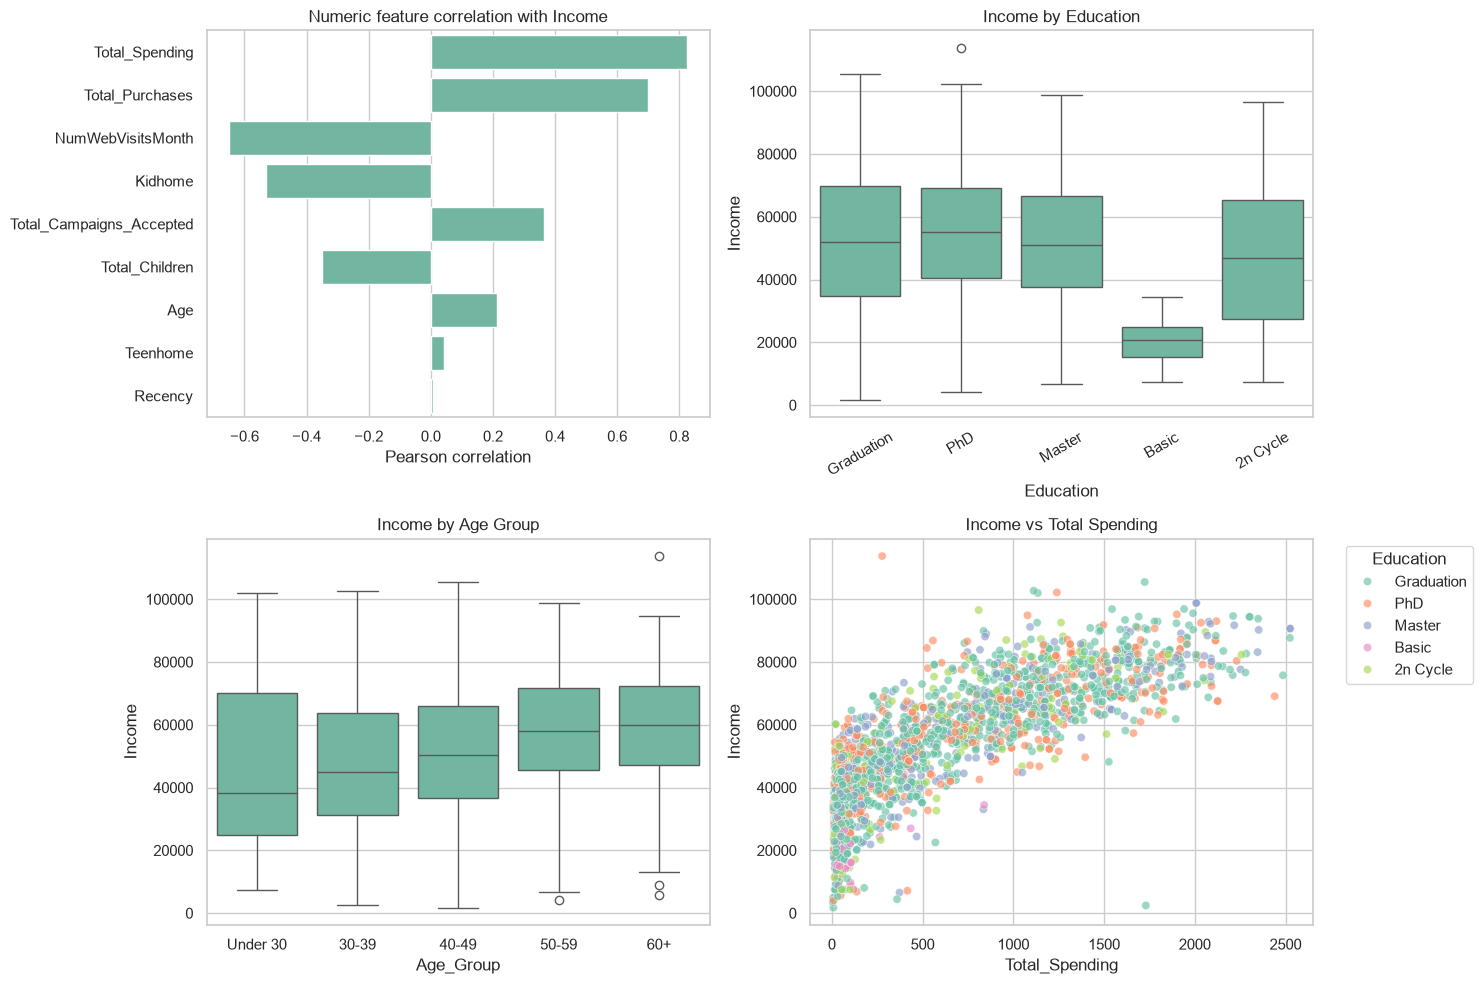

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.barplot(
    data=income_correlations.reset_index(),
    x="income_correlation",
    y="index",
    ax=axes[0, 0],
)
axes[0, 0].set_title("Numeric feature correlation with Income")
axes[0, 0].set_xlabel("Pearson correlation")
axes[0, 0].set_ylabel("")

sns.boxplot(data=known_income, x="Education", y="Income", ax=axes[0, 1])
axes[0, 1].set_title("Income by Education")
axes[0, 1].tick_params(axis="x", rotation=30)

sns.boxplot(data=known_income, x="Age_Group", y="Income", ax=axes[1, 0])
axes[1, 0].set_title("Income by Age Group")

sns.scatterplot(
    data=known_income,
    x="Total_Spending",
    y="Income",
    hue="Education",
    alpha=0.65,
    ax=axes[1, 1],
)
axes[1, 1].set_title("Income vs Total Spending")
axes[1, 1].legend(title="Education", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()

## 11. Group Summary Tables

These tables compare `Income` across important groups.

The notebook shows both `mean` and `median`:

- The **mean** is the regular average.
- The **median** is the middle value after sorting.

For income, the median is usually safer because income often has outliers. A few very high incomes can pull the mean upward and make it less representative of a normal customer in that group.

The tables compare income by:

- education level
- age group
- number of children/teens in the household

These group summaries are the direct evidence used to choose the imputation strategy.


In [11]:
education_income_summary = known_income.groupby("Education")["Income"].agg(["count", "mean", "median"]).sort_values("median", ascending=False)
age_income_summary = known_income.groupby("Age_Group", observed=True)["Income"].agg(["count", "mean", "median"])
children_income_summary = known_income.groupby("Total_Children")["Income"].agg(["count", "mean", "median"])

display(education_income_summary)
display(age_income_summary)
display(children_income_summary)

,count,mean,median
Education,,,
PhD,477,55279.94,55012.00
Graduation,1113,51984.01,51948.00
Master,364,52629.58,50920.50
2n Cycle,200,47633.19,46805.00
Basic,54,20306.26,20744.00


,count,mean,median
Age_Group,,,
Under 30,295,46182.96,38197.00
30-39,601,47639.72,45068.00
40-49,621,51305.81,50437.00
50-59,465,57256.57,58116.00
60+,226,58700.94,59822.00


,count,mean,median
Total_Children,,,
0,629,65123.73,72099.00
1,1114,46960.57,47068.00
2,415,44328.49,44051.00
3,50,46677.00,44277.00


## 12. Fill Missing Income Values

This cell fills missing `Income` values using a step-by-step grouped median approach.

The logic is:

1. First try the most specific group: `Education`, `Marital_Status`, `Age_Group`, and `Total_Children`.
2. If that group does not have enough information, fall back to `Education`, `Age_Group`, and `Total_Children`.
3. If needed, fall back to `Education` and `Age_Group`.
4. If needed, fall back to `Education`.
5. As the final backup, use the overall median income.

This approach keeps the imputed values connected to customer characteristics that are related to income. It is better than using one overall mean because it respects differences between customer groups.

After imputation, the notebook saves the cleaned dataset as `cleaned_marketing_campaign.csv`. This cleaned CSV is the file the clustering notebooks should use. Since the extreme income outlier was removed before saving, the clustering notebooks also use the more realistic income range.


In [12]:
income_by_full_profile = df.groupby(
    ["Education", "Marital_Status", "Age_Group", "Total_Children"], observed=True
)["Income"].transform("median")
income_by_education_age_children = df.groupby(
    ["Education", "Age_Group", "Total_Children"], observed=True
)["Income"].transform("median")
income_by_education_age = df.groupby(["Education", "Age_Group"], observed=True)["Income"].transform("median")
income_by_education = df.groupby("Education")["Income"].transform("median")
overall_income_median = df["Income"].median()

df["Income"] = (
    df["Income"]
    .fillna(income_by_full_profile)
    .fillna(income_by_education_age_children)
    .fillna(income_by_education_age)
    .fillna(income_by_education)
    .fillna(overall_income_median)
)

df.to_csv("cleaned_marketing_campaign.csv", index=False)

cleaning_summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean().mul(100).round(2),
    "unique_count": df.nunique(),
})

cleaning_summary

,dtype,missing_count,missing_percent,unique_count
ID,int64,0,0.00,2232
Year_Birth,int64,0,0.00,59
Education,str,0,0.00,5
Marital_Status,str,0,0.00,8
Income,float64,0,0.00,1979
Kidhome,int64,0,0.00,3
Teenhome,int64,0,0.00,3
Dt_Customer,datetime64[us],0,0.00,663
Recency,int64,0,0.00,100
MntWines,int64,0,0.00,776


## 13. Final Cleaning Result

The final summary table is shown after filling `Income`.

At this point, the missing income values should be filled, the engineered features should be included, and the cleaned CSV should be ready for clustering.

The key cleaning decision is that missing income was filled using group-based medians, supported by the relationship checks and graphs above.


- Izzatkhanim Mirzakhanova
